**[Cell 0] Imports & Constants**

In [1]:
import os, json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from itertools import combinations
from collections import Counter

In [ ]:
IMAGE_ROOT = "../src/datasets/train/DCM"
JSON_ROOT  = "../src/datasets/train/outputs_json"

CLASSES = [
    'finger-1','finger-2','finger-3','finger-4','finger-5',
    'finger-6','finger-7','finger-8','finger-9','finger-10',
    'finger-11','finger-12','finger-13','finger-14','finger-15',
    'finger-16','finger-17','finger-18','finger-19',
    'Trapezium','Trapezoid','Capitate','Hamate',
    'Scaphoid','Lunate','Triquetrum','Pisiform',
    'Radius','Ulna'
]

**[Cell 0-1] Helper: build class masks once per json**

In [3]:
def build_class_masks(anns, shape=(2048, 2048)):
    """
    anns: json["annotations"]
    return: {class_name: binary_mask}
    """
    class_masks = {}

    for ann in anns:
        label = ann["label"]
        canvas = np.zeros(shape, np.uint8)
        pts = np.array(ann["points"], np.int32)
        cv2.fillPoly(canvas, [pts], 1)

        # 같은 class가 여러 polygon일 경우 누적
        if label in class_masks:
            class_masks[label] = np.logical_or(class_masks[label], canvas)
        else:
            class_masks[label] = canvas

    # bool → uint8
    for k in class_masks:
        class_masks[k] = class_masks[k].astype(np.uint8)

    return class_masks

# **PART 1 - Basic Dataset Statistics**

**[Cell 1] Pixel statistics 수집**

In [ ]:
pixel_records = []
mask_count_per_image = []

for root, _, files in tqdm(list(os.walk(JSON_ROOT))):
    for f in files:
        if not f.endswith(".json"):
            continue

        json_path = os.path.join(root, f)
        with open(json_path) as fp:
            anns = json.load(fp)["annotations"]

        rel_json = os.path.relpath(json_path, JSON_ROOT)
        class_pixels = {c: 0 for c in CLASSES}

        class_masks = build_class_masks(anns)

        for c, m in class_masks.items():
            class_pixels[c] += m.sum()

        mask_count_per_image.append(sum(v > 0 for v in class_pixels.values()))

        for c, v in class_pixels.items():
            if v > 0:
                pixel_records.append({
                    "image": rel_json,
                    "class": c,
                    "pixels": v
                })

pixel_df = pd.DataFrame(pixel_records)

  0%|          | 0/401 [00:00<?, ?it/s]

100%|██████████| 401/401 [02:10<00:00,  3.08it/s]


**[Cell 2] Pixel count per class (그래프)**

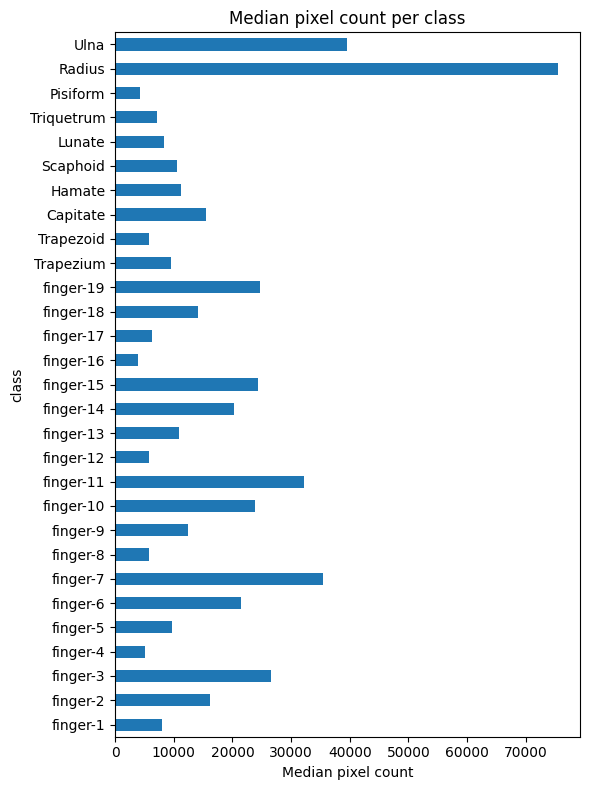

In [14]:
plt.figure(figsize=(6,8))
pixel_df.groupby("class")["pixels"].median().reindex(CLASSES).plot.barh()
plt.xlabel("Median pixel count")
plt.title("Median pixel count per class")
plt.tight_layout()
plt.show()

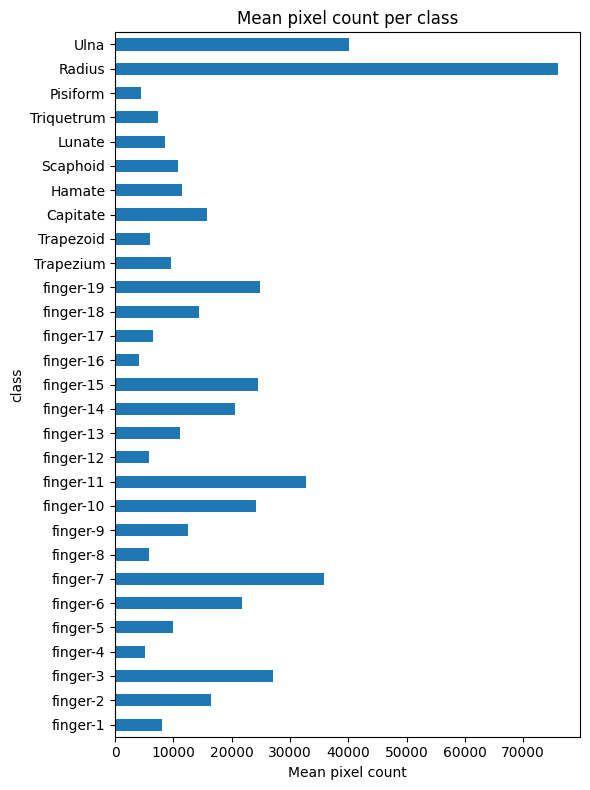

In [5]:
plt.figure(figsize=(6,8))
pixel_df.groupby("class")["pixels"].mean().reindex(CLASSES).plot.barh()
plt.xlabel("Mean pixel count")
plt.title("Mean pixel count per class")
plt.tight_layout()
plt.show()

In [6]:
g = pixel_df.groupby("class")["pixels"]

summary = pd.DataFrame({
    "count": g.size(),
    "mean": g.mean(),
    "median": g.median(),
    "std": g.std(),
})
summary["abs_diff"] = (summary["mean"] - summary["median"]).abs()
summary = summary.reindex(CLASSES)

display(summary.sort_values("abs_diff", ascending=False).head(10))
print("전체 abs_diff 요약:", summary["abs_diff"].describe())


,count,mean,median,std,abs_diff
class,,,,,
Ulna,798,40044.313283,39494.5,6837.172871,549.813283
finger-11,798,32778.479950,32263.0,4306.767459,515.479950
finger-3,798,27070.928571,26604.0,3824.711729,466.928571
Radius,798,75942.547619,75498.0,10134.994644,444.547619
finger-7,798,35852.005013,35476.0,4663.532138,376.005013
finger-10,798,24203.459900,23878.0,3190.926190,325.459900
finger-2,798,16539.687970,16220.5,2397.818126,319.187970
Capitate,798,15831.116541,15544.0,2615.446615,287.116541
Lunate,798,8521.090226,8290.0,1679.211061,231.090226


전체 abs_diff 요약: count     29.000000
mean     215.100726
std      136.830317
min       71.961153
25%      123.486216
50%      161.387218
75%      287.116541
max      549.813283
Name: abs_diff, dtype: float64


<Figure size 1000x400 with 0 Axes>

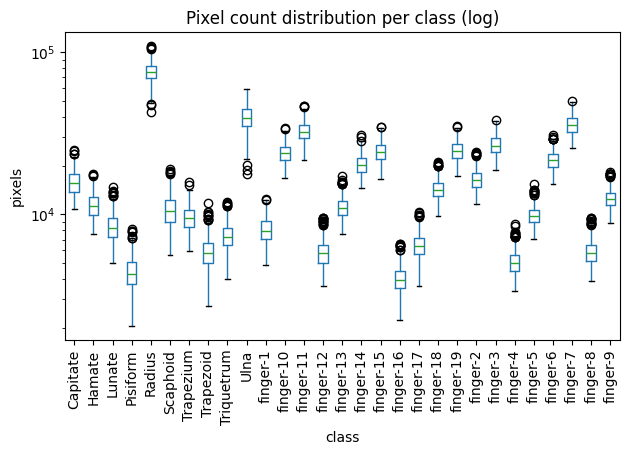

In [7]:
plt.figure(figsize=(10,4))
pixel_df.boxplot(column="pixels", by="class", rot=90, grid=False)
plt.yscale("log")
plt.title("Pixel count distribution per class (log)")
plt.suptitle("")
plt.ylabel("pixels")
plt.tight_layout()
plt.show()


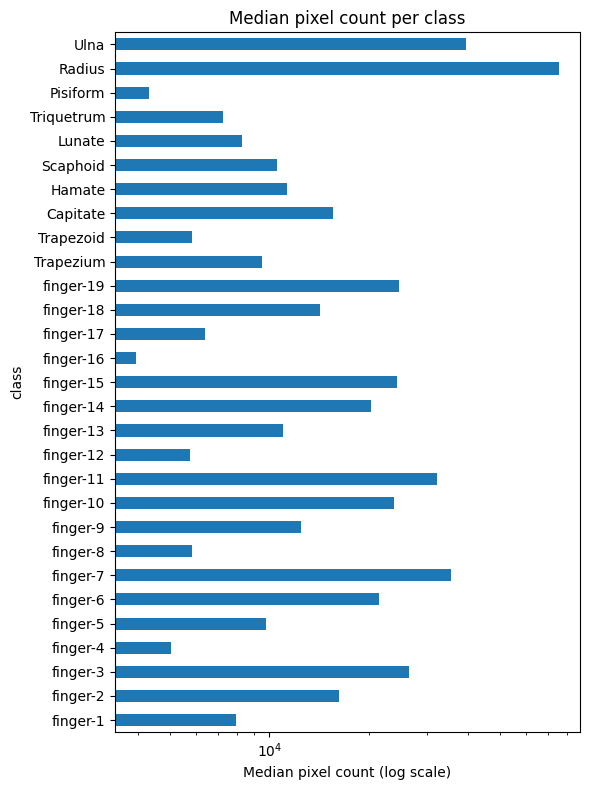

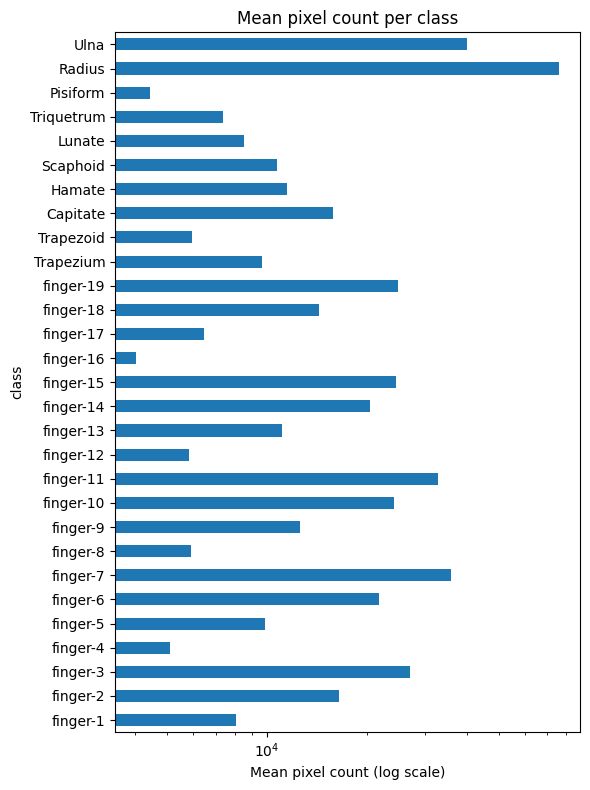

In [8]:
plt.figure(figsize=(6,8))
summary["median"].plot.barh()
plt.xscale("log")
plt.xlabel("Median pixel count (log scale)")
plt.title("Median pixel count per class")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,8))
summary["mean"].plot.barh()
plt.xscale("log")
plt.xlabel("Mean pixel count (log scale)")
plt.title("Mean pixel count per class")
plt.tight_layout()
plt.show()


**[Cell 3] Mask count per image 분포**

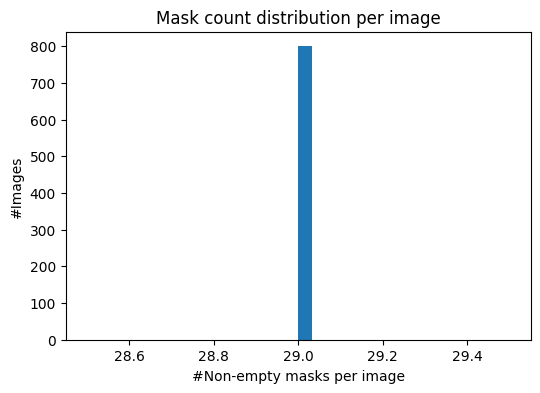

In [15]:
plt.figure(figsize=(6,4))
plt.hist(mask_count_per_image, bins=30)
plt.xlabel("#Non-empty masks per image")
plt.ylabel("#Images")
plt.title("Mask count distribution per image")
plt.show()

# **PART2 - Pixel-level Overlap Analysis**

**[Cell 4] Pixel-level overlap 통계**

In [ ]:
overlap_stats = []

for root, _, files in tqdm(list(os.walk(JSON_ROOT))):
    for f in files:
        if not f.endswith(".json"):
            continue

        json_path = os.path.join(root, f)
        with open(json_path) as fp:
            anns = json.load(fp)["annotations"]

        class_masks = build_class_masks(anns)

        if len(class_masks) < 2:
            continue

        stack = np.stack(list(class_masks.values()))
        overlap_pixels = np.sum(stack.sum(axis=0) >= 2)

        overlap_stats.append({
            "image": os.path.relpath(json_path, JSON_ROOT),
            "overlap_pixels": overlap_pixels
        })

overlap_df = pd.DataFrame(overlap_stats)

100%|██████████| 401/401 [03:59<00:00,  1.67it/s]


**[Cell 5] Overlap distribution**

**[Cell 6] Boundary-adjacent class pairs**

In [ ]:
boundary_pairs = Counter()

for root, _, files in tqdm(list(os.walk(JSON_ROOT))):
    for f in files:
        if not f.endswith(".json"):
            continue

        with open(os.path.join(root, f)) as fp:
            anns = json.load(fp)["annotations"]

        class_masks = build_class_masks(anns)

        for c1, c2 in combinations(class_masks.keys(), 2):
            dilated = cv2.dilate(class_masks[c1], np.ones((3,3), np.uint8))
            if np.any(dilated & class_masks[c2]):
                boundary_pairs[(c1, c2)] += 1

100%|██████████| 401/401 [12:31<00:00,  1.88s/it]


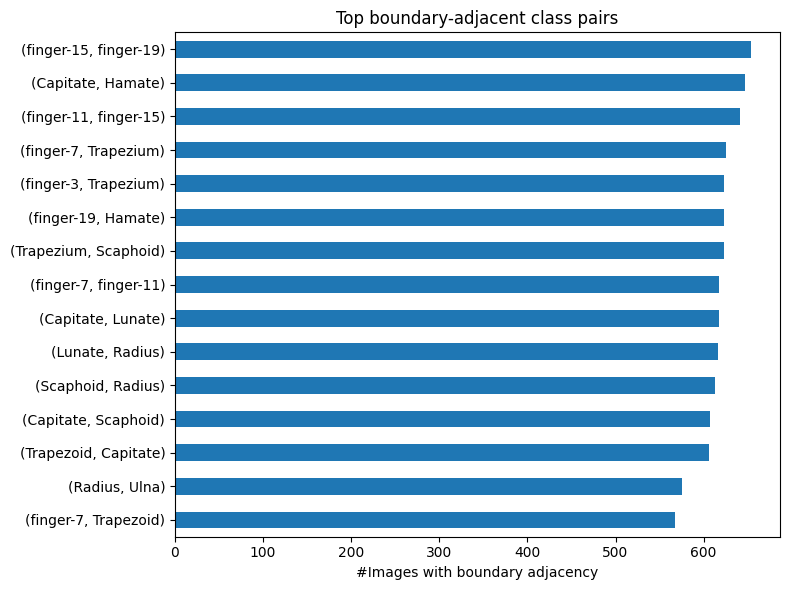

In [19]:
topk = pd.Series(boundary_pairs).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
topk.plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("#Images with boundary adjacency")
plt.title("Top boundary-adjacent class pairs")
plt.tight_layout()
plt.show()

**[Cell 6-1] Overlap class pairs (pixel-level)**

In [ ]:
overlap_pair_counter = Counter()

for root, _, files in tqdm(list(os.walk(JSON_ROOT))):
    for f in files:
        if not f.endswith(".json"):
            continue

        with open(os.path.join(root, f)) as fp:
            anns = json.load(fp)["annotations"]

        class_masks = build_class_masks(anns)

        for c1, c2 in combinations(class_masks.keys(), 2):
            overlap_pixels = np.sum(class_masks[c1] & class_masks[c2])
            if overlap_pixels > 0:
                overlap_pair_counter[(c1, c2)] += overlap_pixels

100%|██████████| 401/401 [19:22<00:00,  2.90s/it]


In [21]:
overlap_pair_df = (
    pd.DataFrame(
        [(k[0], k[1], v) for k, v in overlap_pair_counter.items()],
        columns=["class_1", "class_2", "overlap_pixels"]
    )
    .sort_values("overlap_pixels", ascending=False)
    .reset_index(drop=True)
)

display(overlap_pair_df.head(15))

,class_1,class_2,overlap_pixels
0,Pisiform,Triquetrum,1780156
1,Trapezium,Trapezoid,1355340
2,Triquetrum,Pisiform,1058262
3,Capitate,Scaphoid,868542
4,finger-19,Hamate,853244
5,Capitate,Hamate,815776
6,Lunate,Radius,758116
7,Scaphoid,Radius,718128
8,Capitate,Lunate,711108
9,finger-15,finger-19,596779


**[Cell 6-2] Boundary vs Overlap comparison**

In [22]:
boundary_df = (
    pd.DataFrame(
        [(k[0], k[1], v) for k, v in boundary_pairs.items()],
        columns=["class_1", "class_2", "boundary_count"]
    )
)

compare_df = pd.merge(
    boundary_df,
    overlap_pair_df,
    on=["class_1", "class_2"],
    how="outer"
).fillna(0)

# 보기 좋게 정렬
compare_df = compare_df.sort_values(
    ["overlap_pixels", "boundary_count"],
    ascending=False
)

display(compare_df.head(20))

,class_1,class_2,boundary_count,overlap_pixels
29,Pisiform,Triquetrum,493,1780156.0
47,Trapezium,Trapezoid,565,1355340.0
63,Triquetrum,Pisiform,306,1058262.0
3,Capitate,Scaphoid,607,868542.0
94,finger-19,Hamate,623,853244.0
0,Capitate,Hamate,647,815776.0
23,Lunate,Radius,616,758116.0
40,Scaphoid,Radius,613,718128.0
1,Capitate,Lunate,618,711108.0
87,finger-15,finger-19,654,596779.0


**[Cell 6-3] Tagging for interpretation (핵심 해석용)**

In [23]:
# 기준은 너 데이터 분포 보고 조절하면 됨
BOUNDARY_T = 50
OVERLAP_LOW = 100
OVERLAP_HIGH = 1000

compare_df["pair_type"] = np.select(
    [
        (compare_df["boundary_count"] >= BOUNDARY_T) & (compare_df["overlap_pixels"] <= OVERLAP_LOW),
        (compare_df["boundary_count"] >= BOUNDARY_T) & (compare_df["overlap_pixels"] >= OVERLAP_HIGH),
        (compare_df["boundary_count"] < BOUNDARY_T) & (compare_df["overlap_pixels"] >= OVERLAP_HIGH),
    ],
    [
        "Boundary-only (likely normal adjacency)",
        "Boundary+Overlap (suspicious conflict)",
        "Overlap-only (possible labeling conflict)",
    ],
    default="Other"
)

display(compare_df.head(30))

,class_1,class_2,boundary_count,overlap_pixels,pair_type
29,Pisiform,Triquetrum,493,1780156.0,Boundary+Overlap (suspicious conflict)
47,Trapezium,Trapezoid,565,1355340.0,Boundary+Overlap (suspicious conflict)
63,Triquetrum,Pisiform,306,1058262.0,Boundary+Overlap (suspicious conflict)
3,Capitate,Scaphoid,607,868542.0,Boundary+Overlap (suspicious conflict)
94,finger-19,Hamate,623,853244.0,Boundary+Overlap (suspicious conflict)
0,Capitate,Hamate,647,815776.0,Boundary+Overlap (suspicious conflict)
23,Lunate,Radius,616,758116.0,Boundary+Overlap (suspicious conflict)
40,Scaphoid,Radius,613,718128.0,Boundary+Overlap (suspicious conflict)
1,Capitate,Lunate,618,711108.0,Boundary+Overlap (suspicious conflict)
87,finger-15,finger-19,654,596779.0,Boundary+Overlap (suspicious conflict)


**[Cell 7-1] Boundary-adjacent Heatmap (count of images)**

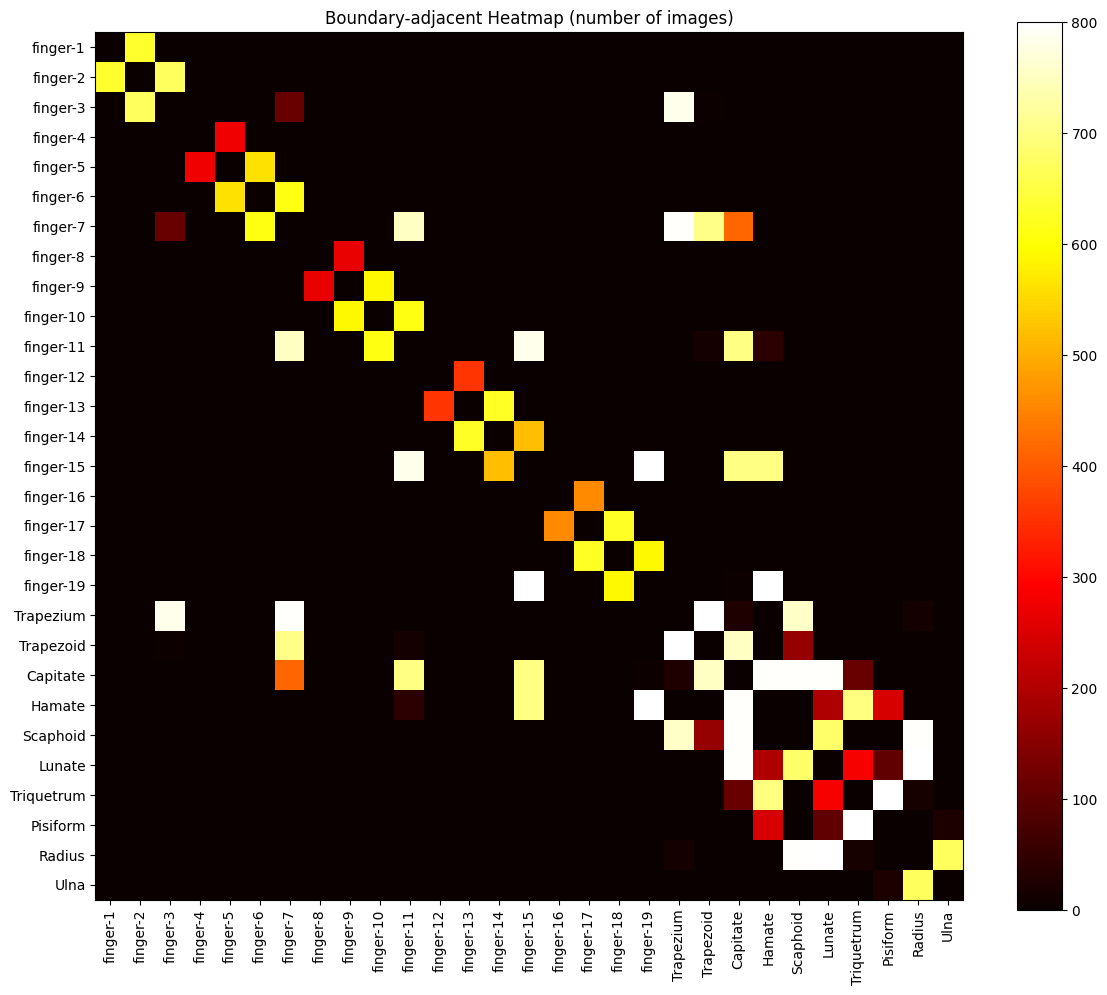

In [24]:
cls2idx = {c: i for i, c in enumerate(CLASSES)}
n = len(CLASSES)
boundary_matrix = np.zeros((n, n), dtype=np.int64)

for (c1, c2), v in boundary_pairs.items():
    i, j = cls2idx[c1], cls2idx[c2]
    boundary_matrix[i, j] += v
    boundary_matrix[j, i] += v

plt.figure(figsize=(12,10))
plt.imshow(boundary_matrix, cmap="hot")
plt.xticks(range(n), CLASSES, rotation=90)
plt.yticks(range(n), CLASSES)
plt.colorbar()
plt.title("Boundary-adjacent Heatmap (number of images)")
plt.tight_layout()
plt.show()

**[Cell 7-2] Overlap Heatmap (sum of overlapping pixels)**

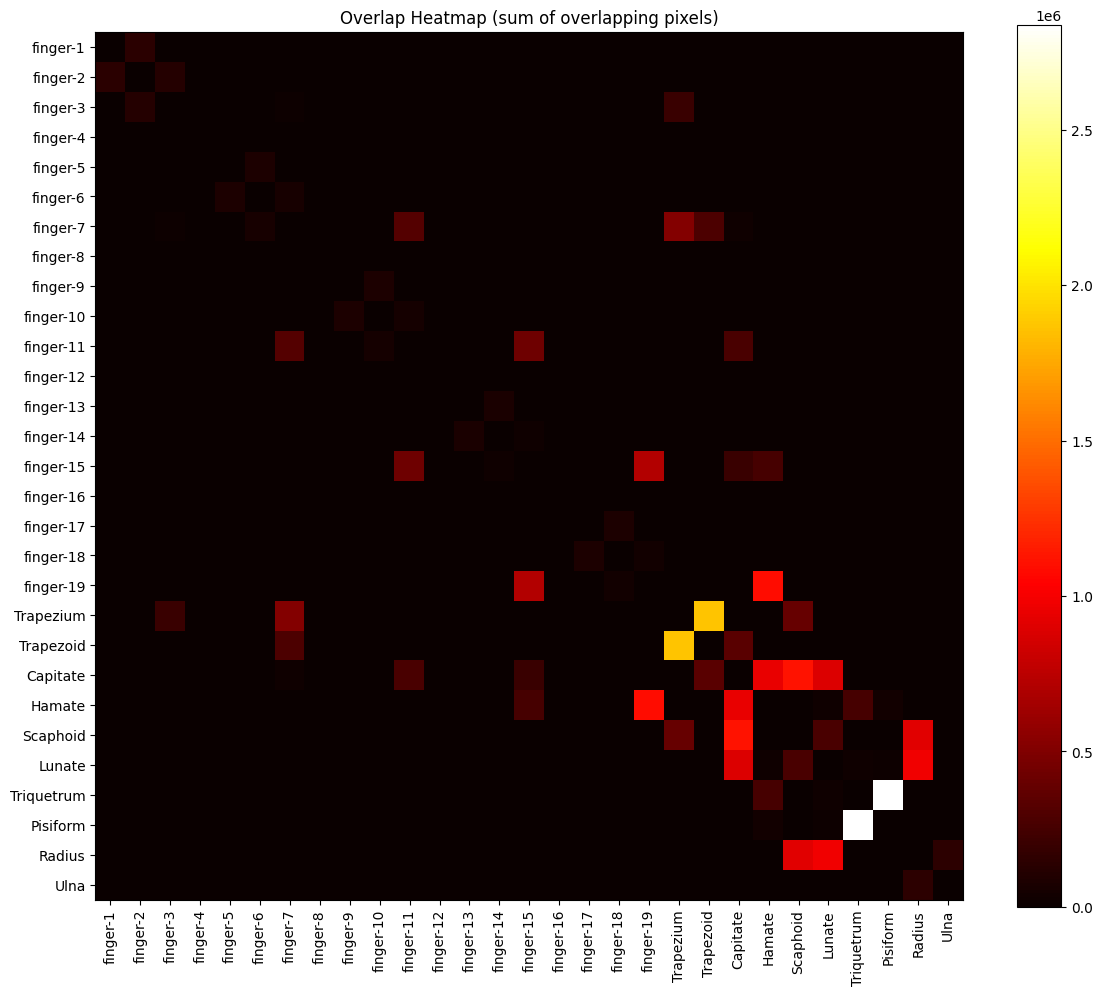

In [25]:
overlap_pixel_matrix = np.zeros((n, n), dtype=np.int64)

for _, r in overlap_pair_df.iterrows():
    c1, c2, v = r["class_1"], r["class_2"], int(r["overlap_pixels"])
    i, j = cls2idx[c1], cls2idx[c2]
    overlap_pixel_matrix[i, j] += v
    overlap_pixel_matrix[j, i] += v

plt.figure(figsize=(12,10))
plt.imshow(overlap_pixel_matrix, cmap="hot")
plt.xticks(range(n), CLASSES, rotation=90)
plt.yticks(range(n), CLASSES)
plt.colorbar()
plt.title("Overlap Heatmap (sum of overlapping pixels)")
plt.tight_layout()
plt.show()

**[Cell 8] Overlap 시각화 함수**

In [ ]:
overlap_df_sorted = overlap_df.sort_values(
    "overlap_pixels", ascending=False
).reset_index(drop=True)

def show_overlap(idx, alpha=0.6):
    if idx < 0 or idx >= len(overlap_df_sorted):
        print("Index out of range:", idx)
        return

    row = overlap_df_sorted.iloc[idx]

    json_path = os.path.join(JSON_ROOT, row["image"])
    img_path = os.path.join(
        IMAGE_ROOT, row["image"].replace(".json", ".png")
    )

    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print("Image not found:", img_path)
        return
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    with open(json_path) as fp:
        anns = json.load(fp)["annotations"]

    class_masks = build_class_masks(anns, shape=img.shape[:2])
    overlap = np.stack(list(class_masks.values())).sum(axis=0) >= 2

    overlay = img.copy()
    overlay[overlap] = [255, 0, 255]
    blended = cv2.addWeighted(overlay, alpha, img, 1-alpha, 0)

    fig, axes = plt.subplots(1,2, figsize=(10,5))
    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(blended)
    axes[1].set_title(f"Overlap pixels = {row['overlap_pixels']}")
    axes[1].axis("off")

    plt.suptitle(row["image"])
    plt.tight_layout()
    plt.show()

**[Cell 8-1] Overlap 실행 셀 (여기만 만짐)**

In [ ]:
IDX_LIST = [0, 1, 2, 5]
ALPHA = 0.6

for idx in IDX_LIST:
    show_overlap(idx, alpha=ALPHA)

# **PART 3 -  Low-pixel Outlier Analysis**

**[Cell 9] Outlier 기준 설정 (조절 노브)**

In [28]:
LOW_PIXEL_QUANTILE = 0.05   # ← 이 값만 바꾸면 됨

pixel_df["low_thr"] = pixel_df.groupby("class")["pixels"].transform(
    lambda x: x.quantile(LOW_PIXEL_QUANTILE)
)

outliers = pixel_df[pixel_df["pixels"] < pixel_df["low_thr"]]
outliers_sorted = outliers.sort_values("pixels").reset_index(drop=True)

print(f"Total potential noisy masks: {len(outliers)}")
display(outliers_sorted.head(10))

Total potential noisy masks: 1158


,image,class,pixels,low_thr
0,ID325/image1664846270124.json,Pisiform,2051,2948.30
1,ID030/image1661317062396.json,Pisiform,2067,2948.30
2,ID111/image1661907848327.json,finger-16,2221,2998.95
3,ID036/image1661318659827.json,Pisiform,2256,2948.30
4,ID072/image1661736317458.json,Pisiform,2327,2948.30
5,ID029/image1661306136685.json,Pisiform,2379,2948.30
6,ID089/image1661821711879.json,Pisiform,2394,2948.30
7,ID548/image1667354167046.json,Pisiform,2424,2948.30
8,ID123/image1661909949990.json,finger-16,2537,2998.95
9,ID126/image1661910986113.json,finger-16,2561,2998.95


**[Cell 9-1] Outlier count per class**

In [29]:
outlier_count = outliers_sorted["class"].value_counts().reindex(CLASSES).fillna(0).astype(int)
display(outlier_count)

class
finger-1      40
finger-2      40
finger-3      40
finger-4      40
finger-5      40
finger-6      40
finger-7      40
finger-8      39
finger-9      40
finger-10     40
finger-11     40
finger-12     40
finger-13     40
finger-14     40
finger-15     40
finger-16     40
finger-17     40
finger-18     40
finger-19     40
Trapezium     40
Trapezoid     40
Capitate      39
Hamate        40
Scaphoid      40
Lunate        40
Triquetrum    40
Pisiform      40
Radius        40
Ulna          40
Name: count, dtype: int64

**[Cell 10] Outlier 시각화 함수 (건드리지 않음)**

In [ ]:
def show_outlier(idx, alpha=0.5):
    if idx < 0 or idx >= len(outliers_sorted):
        print("Index out of range:", idx)
        return

    row = outliers_sorted.iloc[idx]

    json_path = os.path.join(JSON_ROOT, row["image"])
    img_path = os.path.join(
        IMAGE_ROOT, row["image"].replace(".json", ".png")
    )

    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print("Image not found:", img_path)
        return
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    with open(json_path) as fp:
        anns = json.load(fp)["annotations"]

    overlay = img.copy()
    for ann in anns:
        if ann["label"] == row["class"]:
            cv2.fillPoly(
                overlay,
                [np.array(ann["points"], np.int32)],
                (255,0,0)
            )

    blended = cv2.addWeighted(overlay, alpha, img, 1-alpha, 0)

    fig, axes = plt.subplots(1,2, figsize=(10,5))
    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(blended)
    axes[1].set_title(f"{row['class']} | pixels={row['pixels']}")
    axes[1].axis("off")

    plt.suptitle(row["image"])
    plt.tight_layout()
    plt.show()

**[Cell 10-1] 🔥 Outlier 실행 셀 (여기만 만짐)**

In [ ]:
IDX_LIST = [0, 1, 5, 10]
ALPHA = 0.5

for idx in IDX_LIST:
    show_outlier(idx, alpha=ALPHA)

In [9]:
def compute_overlap_stats(class_masks):
    """
    class_masks: {class_name: (H, W) binary mask}
    return:
        class_pixel_count: {class: pixels}
        class_overlap_pixels: {class: overlap_pixels}
    """
    classes = list(class_masks.keys())
    masks = np.stack([class_masks[c] for c in classes], axis=0)  # (C, H, W)

    # 전체 픽셀에서 몇 개 클래스가 활성화됐는지
    active_count = masks.sum(axis=0)  # (H, W)

    overlap_map = active_count >= 2

    class_pixel_count = {}
    class_overlap_pixels = {}

    for i, c in enumerate(classes):
        m = masks[i]
        class_pixel_count[c] = int(m.sum())
        class_overlap_pixels[c] = int((m & overlap_map).sum())

    return class_pixel_count, class_overlap_pixels


In [ ]:
records = []

for root, _, files in tqdm(list(os.walk(JSON_ROOT))):
    for f in files:
        if not f.endswith(".json"):
            continue

        json_path = os.path.join(root, f)
        with open(json_path) as fp:
            anns = json.load(fp)["annotations"]

        class_masks = build_class_masks(anns)

        cls_pixels, cls_overlap = compute_overlap_stats(class_masks)

        for c in CLASSES:
            records.append({
                "class": c,
                "pixels": cls_pixels.get(c, 0),
                "overlap_pixels": cls_overlap.get(c, 0),
            })

df = pd.DataFrame(records)

100%|██████████| 401/401 [08:20<00:00,  1.25s/it]


In [11]:
summary = (
    df.groupby("class")
      .agg(
          mean_pixels=("pixels", "mean"),
          mean_overlap_pixels=("overlap_pixels", "mean")
      )
)

summary["overlap_ratio"] = (
    summary["mean_overlap_pixels"] / summary["mean_pixels"]
)

summary["pixel_minus_overlap"] = (
    summary["mean_pixels"] - summary["mean_overlap_pixels"]
)

summary = summary.reindex(CLASSES)

display(summary)

,mean_pixels,mean_overlap_pixels,overlap_ratio,pixel_minus_overlap
class,,,,
finger-1,8084.887218,172.964912,0.021394,7911.922306
finger-2,16539.687970,324.916040,0.019645,16214.771930
finger-3,27070.928571,420.998747,0.015552,26649.929825
finger-4,5099.961153,4.872180,0.000955,5095.088972
finger-5,9897.486216,115.507519,0.011670,9781.978697
finger-6,21704.652882,180.147870,0.008300,21524.505013
finger-7,35852.005013,1446.169173,0.040337,34405.835840
finger-8,5906.254386,3.665414,0.000621,5902.588972
finger-9,12591.968672,113.096491,0.008982,12478.872180
